# Logistic Regression
In machine learning, logistic regression is used to define a **binary classifier** for **supervised learning**.

# Mathematical Overview
In the realm of statistics, logistic regression is used to estimate the parameters of a **logistic model**.

In statistics, the <b>logistic</b> or <b>logit model</b> is a statistical model based on the <b>logit</b> or <b>log-odds function</b>:
$$
\mathrm{logit}(p) = \log\left(\frac{p}{1-p}\right),\ p\in (0,1)
$$
Here $p$ is interpreted as the probabilty of one of two alternatives (hence the binary classification) and the logit function is considered equal to a linear combination of parameters:
$$
\mathrm{logit}(p) = w_0 + w_1X_1 + w_2X_2 + \dots
$$
Thus, inverting this equality we get the **standard logistic function** or **sigmoid function**:
$$
p(\boldsymbol X) = \frac{1}{1 + e^{-\boldsymbol X}} = \frac{e^{\boldsymbol X}}{e^{\boldsymbol X} + 1}
$$
where $\boldsymbol X$ is the vector $(1, X_1, X_2, \dots)$. Such a function is used to convert so-called log-odds to probabilty values.<br>

<div class="alert alert-block alert-info">
    The two names of this model have different (and sometimes confusing) origins:
<ul>
    <li> <b>Logistic model</b>: comes from the logistic function. </li>
    <li> <b>Logit model</b>: doesn't come from the logit model, but from the work <b>logit</b> as in <i><b>log</b>istic un<b>it</b></i>. </li>
</ul>
</div>

In particular, in machine learning the sigmoid converts the linear combination (dot product) of weights and sample features to probabilties and then acts as an **activation function**: if the resulting value is less then $0.5$ the result is $0$, otherwise the result is $1$.

Since the logistic regression model is fundamentally a fitting algorithm, it is of fundamental importance to **regularization** to prevent overfitting.

# Example
Let's apply the Rosenblatt algorithm to a very well-known dataset, the **breast cancer Wisconsin dataset**. It is characterized by the following properties:
<table style="margin-left: auto; margin-right: auto;">
    <tr>
        <th>Classes</th>
        <td>2</td>
    </tr>
    <tr>
      <th>Samples per class</th>
      <td>212(M), 357(B)</td>
    </tr>
    <tr>
      <th>Samples total</th>
      <td>569</td>
    </tr>
    <tr>
      <th>Dimensionality</th>
      <td>30</td>
    </tr>
    <tr>
      <th>Features</th>
      <td>real, positive</td>
    </tr>
</table>

In [7]:
%matplotlib inline
from sklearn.datasets import load_breast_cancer # For the dataset
from sklearn.model_selection import train_test_split # For splitting the entire dataset in learning and testing subsets
from sklearn.metrics import confusion_matrix, classification_report # For classification evaluation
from sklearn.preprocessing import StandardScaler # For data standardization
from mlpack.logistic_regression import LogisticRegression # Perceptron class
import matplotlib.pyplot as plt # For plotting the loss function

# Load dataset
X, y = load_breast_cancer(return_X_y = True)

# Standardize features
sc = StandardScaler()
X = sc.fit_transform(X=X, y=y)

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3,   # Set proportion of the dataset to include in the testing subset 
    random_state = 42  # Set seed of random generator in order to ensure reproducibility of the results
)

# Instantiate LogisticRegression object
clf = LogisticRegression(
    bias = 0,
    learning_rate = 0.3,
    patience = 100,
    tolerance = 1e-3,
    regularization = 1e-2
)

# Apply learning algorithm to the training subset
#NOTE: it may take some time (depending on set patience) since the underlying training algorithm is not very 
#      efficient right now
clf.fit(X_train, y_train)

# Classify the testing subset
pred = clf.predict(X_test)

# Print sklearn's classification report and the confusion matrix in order to evaluate the learning results
print("==== Classification report ====")
print(classification_report(y_test, pred))

print("==== Confusion matrix ====")
print(confusion_matrix(y_test, pred))

==== Classification report ====
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        63
           1       0.99      0.96      0.98       108

    accuracy                           0.97       171
   macro avg       0.96      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

==== Confusion matrix ====
[[ 62   1]
 [  4 104]]


# Loss Function
The loss function of logistic regression is called the **mean log-loss**:
$$
l(\boldsymbol y, \boldsymbol y') = -\frac{1}{S} [\boldsymbol y^T \log(\boldsymbol y') + (\boldsymbol 1 - \boldsymbol y)^T \log(\boldsymbol 1 - \boldsymbol y')]
$$
This is a (not-so-common) vectorial formulation, usually it is just expressed using scalars and a summation sign at the beginning.

<div class="alert alert-block alert-info">
    In theory, one could use the simpler (total) log-loss function. However, the mean log-loss is more desirable in practice as it separates two important processes: batch size tuning and learning rate tuning. 
</div>

As for other classifiers, the library allows to see the loss function evolution over training epochs of a classifier using the `plot_loss_curve()` method.

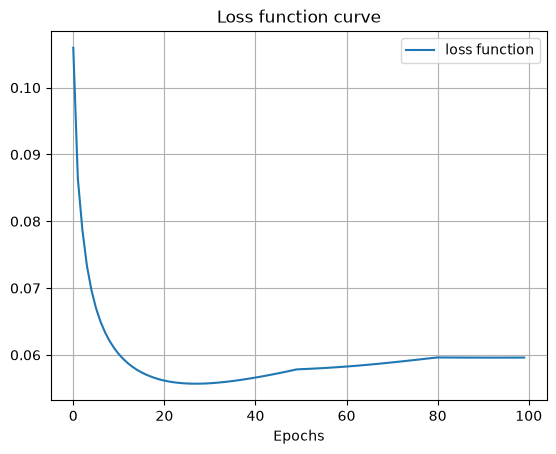

In [6]:
# Visualize loss function
clf.plot_loss_curve(label="loss function")

plt.show()

# Resources
- The relevant [Wikipedia page](https://en.wikipedia.org/wiki/Logistic_regression).
- Wikipedia page on the [logit function](https://en.wikipedia.org/wiki/Logit).
- Wikipedia page on the [logistic function](https://en.wikipedia.org/wiki/Logistic_function).
- Medium article on [logistic regression](https://medium.com/@kaleemullahyounas123/logistic-regression-technique-for-classification-problems-639000510fe5).
- Google's article on [logistic regression's loss function and regularization](https://developers.google.com/machine-learning/crash-course/logistic-regression/loss-regularization).